# Corruption risk indicator calculation

In this notebook i will calculate the corruption risk indicators



statsmodels

https://www.statsmodels.org/stable/examples/notebooks/generated/discrete_choice_example.html#Exercise:-Logit-vs-Probit

In [1]:
import pandas as pd
import numpy as np
from pyprojroot import here
import statsmodels.api as sm
import statsmodels.formula.api as smf
#from unidecode import unidecode
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import utils
#from patsy import dmatrices

processed_data = here('data/processed_data')
figures_folder = here('figures/')
base_name_figures = '9cri_'

In [2]:
var2keep = [
    #identifiers
    'supplier_name_clean',
    #'contract_code',
    'contract_initial_date',
    'contract_price_mx',
    'purchasing_unit_id',

    #dependent variable
    'single_bidder',

    #indepedent variables
    'call_for_tender_publication',
    'procedure_type',
    'procedure_type_fixed',
    'submission_period',
    'decision_period',
    'buyer_dependence',
    'bl_conformity',
    #'contract_price_mx',

    #controls
    'contract_year',    
    'contract_price_decile',
    'government_level',
    'supply_type',
    'state']

In [3]:
#read feather
contracts = pd.read_feather(processed_data / 'mxc_cricomponents.feather', columns=var2keep)
contracts_work = contracts.copy()
contracts_work.shape


(2308908, 17)

In [4]:
(contracts_work.isnull().sum() / contracts_work.shape[0]).sort_index()

bl_conformity                  0.000000
buyer_dependence               0.000000
call_for_tender_publication    0.000000
contract_initial_date          0.000000
contract_price_decile          0.000000
contract_price_mx              0.000000
contract_year                  0.000000
decision_period                0.282378
government_level               0.000000
procedure_type                 0.002651
procedure_type_fixed           0.002651
purchasing_unit_id             0.000000
single_bidder                  0.879292
state                          0.419075
submission_period              0.310234
supplier_name_clean            0.000000
supply_type                    0.003249
dtype: float64

## Keep only experience bidders

In [5]:
experienced_bidders = contracts_work[['supplier_name_clean']]
experienced_bidders = experienced_bidders.groupby(['supplier_name_clean']).size().reset_index(name='count')
#keep only suppliers with more than 2
experienced_bidders = experienced_bidders[experienced_bidders['count'] > 2]
len(experienced_bidders['supplier_name_clean'].unique()) / len(contracts_work['supplier_name_clean'].unique())


0.42240323040526484

In [6]:
experienced_bidders = list(experienced_bidders['supplier_name_clean'])

In [7]:
#keep only experienced bidders
print(contracts_work.shape)
shape_all = contracts_work.shape[0]
contracts_work = contracts_work[contracts_work['supplier_name_clean'].isin(experienced_bidders)]
print(contracts_work.shape)
shape_all - contracts_work.shape[0]

(2308908, 17)
(2113415, 17)


195493

# keep only relevant contracts for logit

In [8]:
len(contracts_work) - len(contracts_work[contracts_work['single_bidder'].isnull() == False])

1840723

In [9]:
contracts_work = contracts_work[contracts_work['single_bidder'].isnull() == False].reset_index(drop=True)

In [10]:
contracts_work['contract_year'].value_counts(dropna=False)

2022    63516
2021    58964
2019    58940
2020    47083
2018    39198
2017     4986
2016        5
Name: contract_year, dtype: int64

In [11]:
contracts_work = contracts_work[contracts_work['contract_year'] != 2016].reset_index(drop=True)

In [12]:
contracts_work['contract_year'].value_counts(dropna=False)

2022    63516
2021    58964
2019    58940
2020    47083
2018    39198
2017     4986
Name: contract_year, dtype: int64

In [13]:
contracts_work.shape

(272687, 17)

# Recodify controls

The controls I used for the regression are:

    Contract year
    Contract price quantiles (10) 
    Buyer type  #no control since ther are only contracts of federal authority
    Supply type 
    Buyer region: has a high missing rate
    Please note that missing values are coded to a separate group 

### Contract year

In [14]:
#one hot encoding contract_year
contracts_work = pd.get_dummies(contracts_work, columns=['contract_year'], prefix=['contract_year'], dummy_na=False, dtype=float)

In [15]:
#drop 2017 because its already counted in the other
contracts_work = contracts_work.drop(columns=['contract_year_2017'])

### Contract price quantile


In [16]:
contracts_work['contract_price_decile'].describe()

count    272687.000000
mean          4.425785
std           3.208554
min           0.000000
25%           1.000000
50%           5.000000
75%           7.000000
max           9.000000
Name: contract_price_decile, dtype: float64

In [17]:
contracts_work['contract_price_decile'].isnull().sum()

0

### Buyer type

In [18]:
contracts_work['government_level'].value_counts(dropna=False)

federal_authority    272687
Name: government_level, dtype: int64

In [19]:
contracts_work = contracts_work.drop(columns=['government_level'])

### Supply type

In [20]:
contracts_work['supply_type'].value_counts(dropna=False)

goods       207252
services     53879
works         8062
NaN           3494
Name: supply_type, dtype: int64

In [21]:
#one hot encoding government level
contracts_work = pd.get_dummies(contracts_work, columns=['supply_type'], prefix=['supply_type'], dummy_na=True, dtype=float)

In [22]:
contracts_work

,supplier_name_clean,contract_initial_date,contract_price_mx,purchasing_unit_id,single_bidder,call_for_tender_publication,procedure_type,procedure_type_fixed,submission_period,decision_period,...,state,contract_year_2018,contract_year_2019,contract_year_2020,contract_year_2021,contract_year_2022,supply_type_goods,supply_type_services,supply_type_works,supply_type_nan
0,diaaproysadecv,2017-07-01,8700000.00,016RHQ001,0.0,1,open,open,39.0,24.0,...,jalisco,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,amarefsadecv,2017-07-01,12384993.00,016RHQ001,0.0,1,open,open,39.0,24.0,...,jalisco,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,consultoresparalainvestigacionaplicadayeldesar...,2017-07-01,33932850.00,016RHQ001,0.0,1,open,open,39.0,24.0,...,jalisco,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,olivaresplataconsultoressadecv,2017-12-08,9051724.15,020G00001,0.0,1,open,open,12.0,10.0,...,ciudaddemexico,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,madelsocorroavinamedina,2017-09-05,403609.00,050GYR025,1.0,1,direct,direct_failed_open,7.0,5.0,...,ciudaddemexico,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272682,jonathanemmanuelhernandezmunoz,2022-01-01,794400.00,050GYR027,0.0,1,open,open,12.0,8.0,...,guanajuato,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
272683,adolfotrejoserviciosespecialessadecv,2022-02-01,1332611.20,050GYR025,0.0,1,at_least_three,at_least_three,6.0,1.0,...,ciudaddemexico,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
272684,inntecsainnovaciontecnologicaparalasaludsadecv,2022-01-28,755484.20,050GYR025,0.0,1,open,open,44.0,6.0,...,ciudaddemexico,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
272685,inntecsainnovaciontecnologicaparalasaludsadecv,2022-01-28,1200120.18,050GYR025,0.0,1,open,open,44.0,6.0,...,ciudaddemexico,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [23]:
contracts_work = contracts_work.drop(columns=['supply_type_nan'])

### Buyer region

In [24]:
contracts_work['state'].value_counts(dropna=False)

NaN                  88075
ciudaddemexico       51781
jalisco              13626
veracruz             11199
mexico               11198
sonora                9118
coahuila              7174
morelos               6896
guanajuato            6716
puebla                6705
chihuahua             5783
nayarit               5270
chiapas               5036
yucatan               4163
michoacan             3706
hidalgo               3608
durango               3267
bajacalifornia        3010
quintanaroo           3007
zacatecas             2635
colima                2622
sanluispotosi         2055
nuevoleon             1973
queretaro             1936
aguascalientes        1819
campeche              1783
oaxaca                1532
tlaxcala              1442
bajacaliforniasur     1217
tabasco               1172
sinaloa               1105
guerrero              1105
tamaulipas             953
Name: state, dtype: int64

In [25]:
contracts_work = pd.get_dummies(contracts_work, columns=['state'], prefix=['region'], dummy_na=True, dtype=float)

In [26]:
contracts_work = contracts_work.drop(columns=['region_nan'])

# Recodify and relevel independent variables

The references should be the least propense to corruption

Call for tender publication - DONT INCLUDE SINCE THERE'S NO VARIANCE

Procedure type - relevel is done in the formula (open as reference)

Submission period - continue as numerical, before running the logit delete observations that don't have submission period for non-null values of single bidder

Decision period - continue as numerical, before running the logit delete observations that don't have decision period for non-null values of single bidder

Buyer dependence - continue as numerical, no changes

Bl conformity - relevel is done in formula (acceptable as reference)

### call for tender publication

In [27]:
contracts_work['call_for_tender_publication'].value_counts(dropna=False)

1    272687
Name: call_for_tender_publication, dtype: int64

In [28]:
#drop variable
contracts_work = contracts_work.drop(columns=['call_for_tender_publication'])

### Procedure_type

In [29]:
contracts_work['procedure_type_fixed'].value_counts(dropna=False)

direct_failed_open    153653
open                   79408
at_least_three         39580
direct                    22
other                     16
NaN                        8
Name: procedure_type_fixed, dtype: int64

In [30]:
len(contracts_work)

272687

In [31]:
contracts_work = contracts_work[contracts_work['procedure_type_fixed'] != 'direct']
contracts_work = contracts_work[contracts_work['procedure_type_fixed'] != 'other']
contracts_work = contracts_work[contracts_work['procedure_type_fixed'].isnull() == False]

In [32]:
contracts_work['procedure_type_fixed'].value_counts(dropna=False)

direct_failed_open    153653
open                   79408
at_least_three         39580
Name: procedure_type_fixed, dtype: int64

In [33]:
len(contracts_work)

272641

In [34]:
#convert to categorical
contracts_work['procedure_type_fixed'] = contracts_work['procedure_type_fixed'].astype('category')
#get list of categories
categories_ptf = contracts_work['procedure_type_fixed'].cat.categories.tolist()
#remove the 'open' reference from the list and add it at the beggining
categories_ptf.remove('open')
categories_ptf = ['open'] + categories_ptf

contracts_work['procedure_type_fixed'] = contracts_work['procedure_type_fixed'].cat.reorder_categories(categories_ptf, ordered=False)

### submission period

In [35]:
pd.crosstab(contracts_work['submission_period'].isnull(), contracts_work['single_bidder'].isnull())

single_bidder,False
submission_period,
False,272641


In [36]:
contracts_work['submission_period'].describe()

count    272641.000000
mean          9.923302
std          11.590413
min        -365.000000
25%           4.000000
50%           7.000000
75%          15.000000
max         365.000000
Name: submission_period, dtype: float64

In [37]:
contracts_work['submission_period'] = np.where(contracts_work['submission_period'] < 0, np.nan, contracts_work['submission_period'])

In [38]:
contracts_work['submission_period'].describe()

count    271652.000000
mean         10.152489
std           9.816988
min           0.000000
25%           4.000000
50%           7.000000
75%          15.000000
max         365.000000
Name: submission_period, dtype: float64

In [39]:
contracts_work[contracts_work['submission_period'] == 0]

,supplier_name_clean,contract_initial_date,contract_price_mx,purchasing_unit_id,single_bidder,procedure_type,procedure_type_fixed,submission_period,decision_period,buyer_dependence,...,region_quintanaroo,region_sanluispotosi,region_sinaloa,region_sonora,region_tabasco,region_tamaulipas,region_tlaxcala,region_veracruz,region_yucatan,region_zacatecas
57,gruponacionalprovincialsab,2017-08-01,48168029.00,008IZC999,1.0,open,open,0.0,0.0,0.139637,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
109,stabilityinmaisonsadecv,2017-06-01,131678.40,050GYR069,1.0,direct,direct_failed_open,0.0,1.0,0.000881,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
212,oscaralejandrogarciatorres,2017-12-11,298242.62,050GYR072,1.0,direct,direct_failed_open,0.0,1.0,0.215023,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
775,vlhhernandezwebersc,2017-05-30,256400.00,002000999,0.0,direct,direct_failed_open,0.0,0.0,0.000660,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
809,placidonunezcrespo,2017-03-01,60000.00,008I6L002,0.0,direct,direct_failed_open,0.0,0.0,0.498567,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271557,mkhumana,2022-01-01,11886297.20,050GYR046,1.0,direct,direct_failed_open,0.0,0.0,0.042196,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
272050,vitalmexinternacionalsadecv,2022-01-01,24933731.20,050GYR046,1.0,direct,direct_failed_open,0.0,0.0,0.100340,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
272099,reactivosyquimicossadecv,2022-01-01,4254827.59,050GYR004,1.0,direct,direct_failed_open,0.0,0.0,0.006626,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
272656,hisafarmaceuticasadecv,2022-01-19,231992.70,050GYR027,0.0,direct,direct_failed_open,0.0,0.0,0.001623,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
contracts_work['submission_period'].isnull().sum()

989

### decision period

In [41]:
pd.crosstab(contracts_work['decision_period'].isnull(), contracts_work['single_bidder'].isnull())

single_bidder,False
decision_period,
False,272641


In [42]:
contracts_work['decision_period'].describe()

count    272641.000000
mean          3.904156
std           9.957924
min        -365.000000
25%           0.000000
50%           0.000000
75%           6.000000
max         365.000000
Name: decision_period, dtype: float64

In [43]:
contracts_work['decision_period'] = np.where(contracts_work['decision_period'] < 0, np.nan, contracts_work['decision_period'])

In [44]:
contracts_work['decision_period'].describe()

count    271062.000000
mean          4.072408
std           8.312071
min           0.000000
25%           0.000000
50%           0.000000
75%           6.000000
max         365.000000
Name: decision_period, dtype: float64

In [45]:
contracts_work['decision_period'].isnull().sum()

1579

### Buyer dependence

In [46]:
contracts_work['buyer_dependence'].describe()

count    2.726410e+05
mean     1.739127e-02
std      6.061772e-02
min      1.346177e-10
25%      6.118910e-04
50%      2.509753e-03
75%      1.059873e-02
max      1.000000e+00
Name: buyer_dependence, dtype: float64

In [47]:
pd.crosstab(contracts_work['buyer_dependence'].isnull(), contracts_work['single_bidder'].isnull())

single_bidder,False
buyer_dependence,
False,272641


### benford conformity

In [48]:
contracts_work['bl_conformity'].value_counts(dropna = False)

2_acceptable_conformity    112888
0_no_conformity             63267
3_high_conformity           55923
1_marginally_acceptable     26300
non_applicable              14263
Name: bl_conformity, dtype: int64

In [49]:
contracts_work['bl_conformity'] = np.where(contracts_work['bl_conformity'].isnull(), 'non_applicable', contracts_work['bl_conformity'])

In [50]:
contracts_work['bl_conformity'].value_counts(dropna = False)

2_acceptable_conformity    112888
0_no_conformity             63267
3_high_conformity           55923
1_marginally_acceptable     26300
non_applicable              14263
Name: bl_conformity, dtype: int64

In [51]:
#convert to  categorical
contracts_work['bl_conformity'] = contracts_work['bl_conformity'].astype('category')
#get list of categories
categories_blc = contracts_work['bl_conformity'].cat.categories.tolist()
#remove the 'open' reference from the list and add it at the beggining
categories_blc.remove('3_high_conformity')
categories_blc = ['3_high_conformity'] + categories_blc

contracts_work['bl_conformity'] = contracts_work['bl_conformity'].cat.reorder_categories(categories_blc, ordered=False)


# Thresholds

### preprocess df for thresholds

In [52]:
contracts_work.shape

(272641, 52)

In [53]:
contracts_work.columns

Index(['supplier_name_clean', 'contract_initial_date', 'contract_price_mx',
       'purchasing_unit_id', 'single_bidder', 'procedure_type',
       'procedure_type_fixed', 'submission_period', 'decision_period',
       'buyer_dependence', 'bl_conformity', 'contract_price_decile',
       'contract_year_2018', 'contract_year_2019', 'contract_year_2020',
       'contract_year_2021', 'contract_year_2022', 'supply_type_goods',
       'supply_type_services', 'supply_type_works', 'region_aguascalientes',
       'region_bajacalifornia', 'region_bajacaliforniasur', 'region_campeche',
       'region_chiapas', 'region_chihuahua', 'region_ciudaddemexico',
       'region_coahuila', 'region_colima', 'region_durango',
       'region_guanajuato', 'region_guerrero', 'region_hidalgo',
       'region_jalisco', 'region_mexico', 'region_michoacan', 'region_morelos',
       'region_nayarit', 'region_nuevoleon', 'region_oaxaca', 'region_puebla',
       'region_queretaro', 'region_quintanaroo', 'region_sanluis

In [54]:
control_variables = contracts_work.filter(like='contract_year', axis=1).columns.tolist() + ['contract_price_decile'] + contracts_work.filter(like='supply_type', axis=1).columns.tolist() + contracts_work.filter(like='region', axis=1).columns.tolist()
independent_variables = ['procedure_type_fixed', 'submission_period', 'decision_period', 'buyer_dependence', 'bl_conformity']
dependent_variable = ['single_bidder']

In [55]:
print(control_variables)

['contract_year_2018', 'contract_year_2019', 'contract_year_2020', 'contract_year_2021', 'contract_year_2022', 'contract_price_decile', 'supply_type_goods', 'supply_type_services', 'supply_type_works', 'region_aguascalientes', 'region_bajacalifornia', 'region_bajacaliforniasur', 'region_campeche', 'region_chiapas', 'region_chihuahua', 'region_ciudaddemexico', 'region_coahuila', 'region_colima', 'region_durango', 'region_guanajuato', 'region_guerrero', 'region_hidalgo', 'region_jalisco', 'region_mexico', 'region_michoacan', 'region_morelos', 'region_nayarit', 'region_nuevoleon', 'region_oaxaca', 'region_puebla', 'region_queretaro', 'region_quintanaroo', 'region_sanluispotosi', 'region_sinaloa', 'region_sonora', 'region_tabasco', 'region_tamaulipas', 'region_tlaxcala', 'region_veracruz', 'region_yucatan', 'region_zacatecas']


In [56]:
contracts_work.isnull().sum()

supplier_name_clean            0
contract_initial_date          0
contract_price_mx              0
purchasing_unit_id             0
single_bidder                  0
procedure_type                 0
procedure_type_fixed           0
submission_period            989
decision_period             1579
buyer_dependence               0
bl_conformity                  0
contract_price_decile          0
contract_year_2018             0
contract_year_2019             0
contract_year_2020             0
contract_year_2021             0
contract_year_2022             0
supply_type_goods              0
supply_type_services           0
supply_type_works              0
region_aguascalientes          0
region_bajacalifornia          0
region_bajacaliforniasur       0
region_campeche                0
region_chiapas                 0
region_chihuahua               0
region_ciudaddemexico          0
region_coahuila                0
region_colima                  0
region_durango                 0
region_gua

In [57]:
#drop procedure_type
contracts_work = contracts_work.drop(columns=['procedure_type'])


In [58]:
contracts_work.shape

(272641, 51)

# threshold submission period

single_bidder ~ submission_period+contract_year_2018+contract_year_2019+contract_year_2020+contract_year_2021+contract_year_2022+contract_price_decile+supply_type_goods+supply_type_services+supply_type_works+region_aguascalientes+region_bajacalifornia+region_bajacaliforniasur+region_campeche+region_chiapas+region_chihuahua+region_ciudaddemexico+region_coahuila+region_colima+region_durango+region_guanajuato+region_guerrero+region_hidalgo+region_jalisco+region_mexico+region_michoacan+region_morelos+region_nayarit+region_nuevoleon+region_oaxaca+region_puebla+region_queretaro+region_quintanaroo+region_sanluispotosi+region_sinaloa+region_sonora+region_tabasco+region_tamaulipas+region_tlaxcala+region_veracruz+region_yucatan+region_zacatecas
Optimization terminated successfully.
         Current function value: 0.290610
         Iterations 8


/mnt/sdb1/marti/detecting_corruption_mexico/scripts/dataset_creation/utils.py:164: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2process['residuals'] = logit_model.resid_response


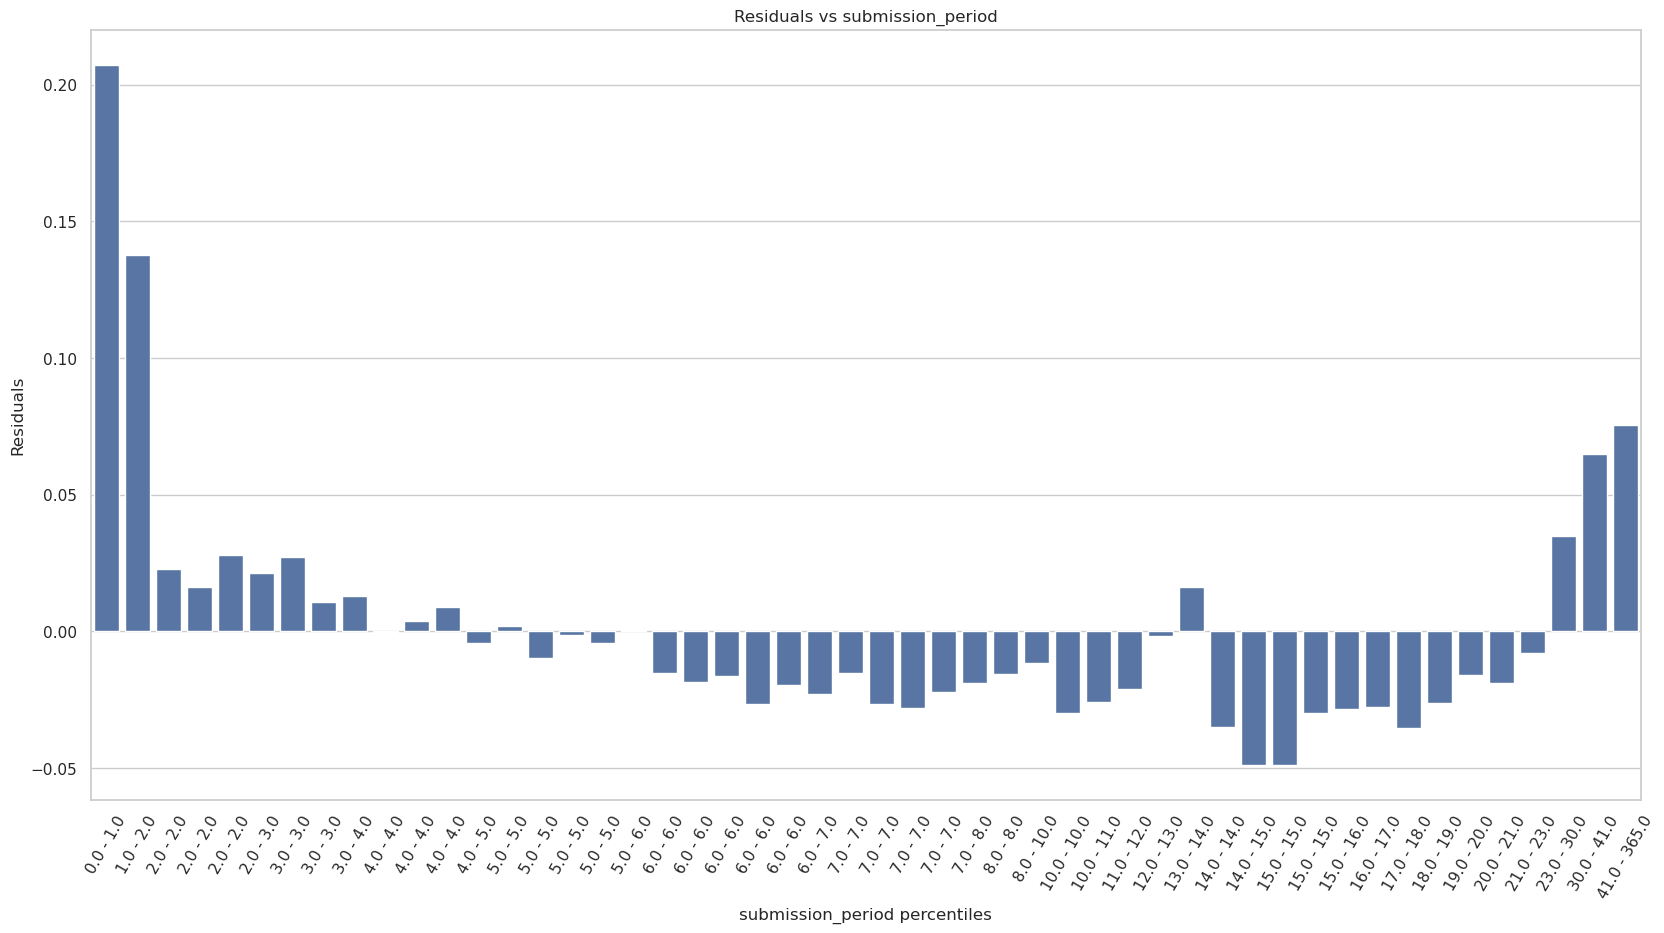

In [59]:
residuals_sp = utils.variable_vs_residuals_df(preprocessed_df = contracts_work,
                            variable2threshold = 'submission_period',                            
                            control_variables = control_variables,
                            number_of_quantiles = 50)
utils.plot_variableVSresiduals(df_varVSresiduals = residuals_sp, 
                        variable2threshold = 'submission_period',
                        wthresholds_plot = False)

In [60]:
#show me 10 quantiles
contracts_work['submission_period'].quantile([0.33, 0.66, 1])

0.33      5.0
0.66     11.0
1.00    365.0
Name: submission_period, dtype: float64

single_bidder ~ submission_period+contract_year_2018+contract_year_2019+contract_year_2020+contract_year_2021+contract_year_2022+contract_price_decile+supply_type_goods+supply_type_services+supply_type_works+region_aguascalientes+region_bajacalifornia+region_bajacaliforniasur+region_campeche+region_chiapas+region_chihuahua+region_ciudaddemexico+region_coahuila+region_colima+region_durango+region_guanajuato+region_guerrero+region_hidalgo+region_jalisco+region_mexico+region_michoacan+region_morelos+region_nayarit+region_nuevoleon+region_oaxaca+region_puebla+region_queretaro+region_quintanaroo+region_sanluispotosi+region_sinaloa+region_sonora+region_tabasco+region_tamaulipas+region_tlaxcala+region_veracruz+region_yucatan+region_zacatecas
Optimization terminated successfully.
         Current function value: 0.290610
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.285745
         Iterations 8


/mnt/sdb1/marti/detecting_corruption_mexico/scripts/dataset_creation/utils.py:150: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2process['residuals'] = logit_model.resid_response


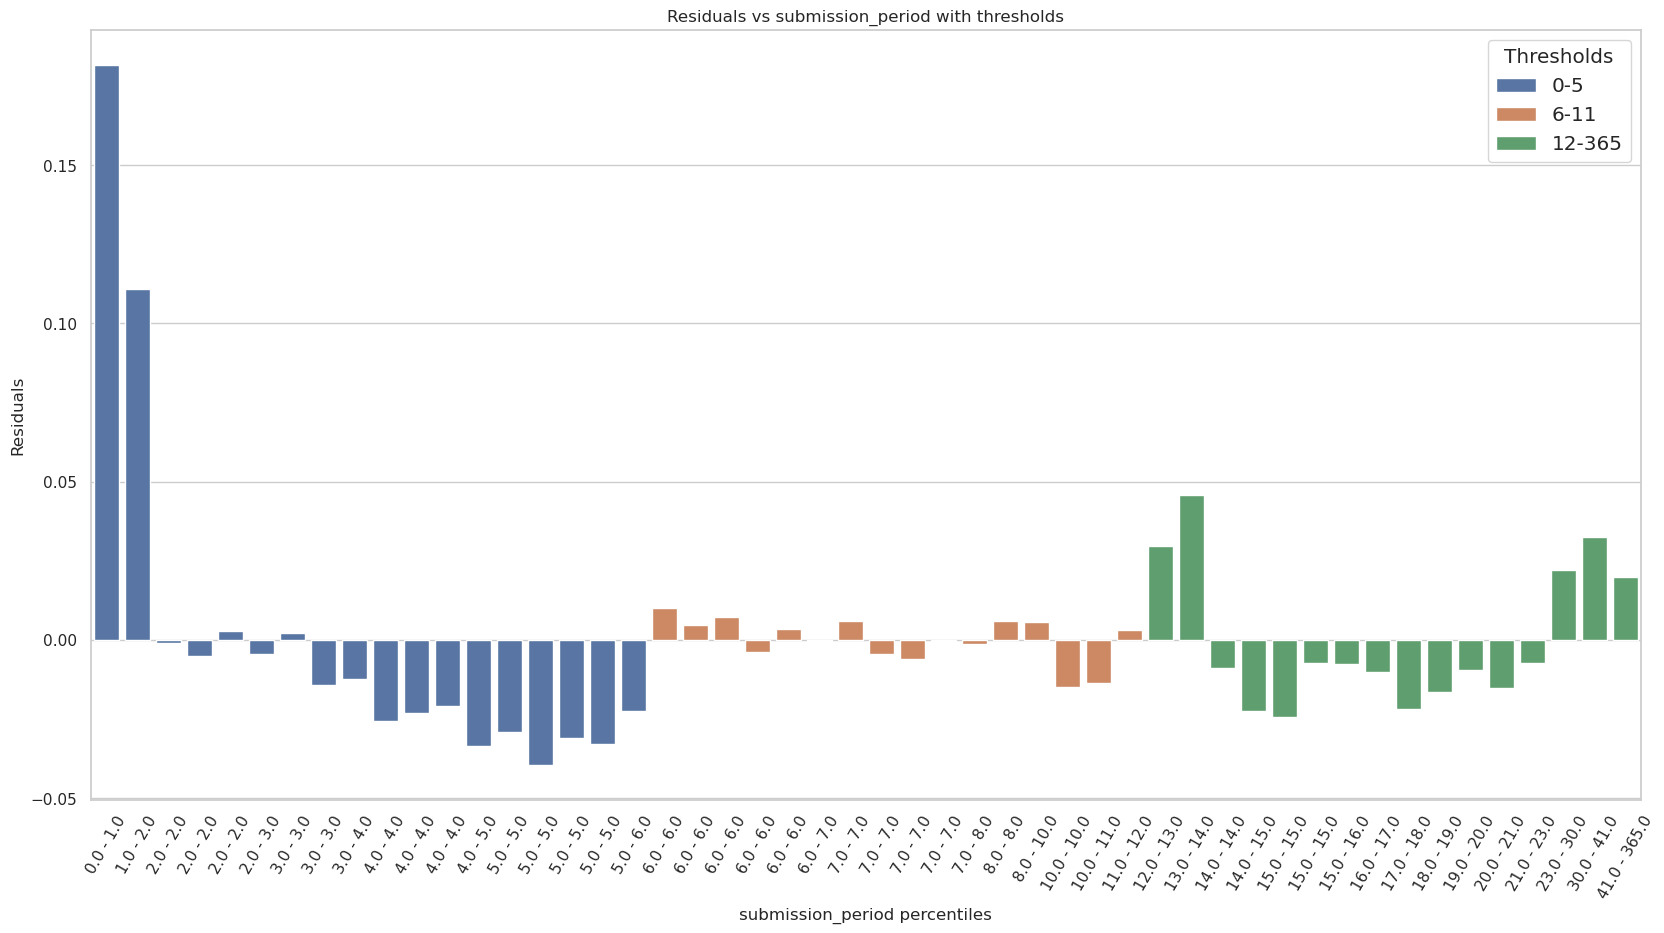

In [61]:
submission_period_bins = [-1, 5, 11, 366]
submission_period_binslabels = ['0-5', '6-11', '12-365']
## threshold decision period ['-365-2', '3-5', '6-14', '15-365']
residuals_sp_wt = utils.variable_vs_residuals_df(preprocessed_df = contracts_work,
                            variable2threshold = 'submission_period',                            
                            control_variables = control_variables,
                            number_of_quantiles = 50,
                            thresholds_m = submission_period_bins,
                            thresholds_labels = submission_period_binslabels)

utils.plot_variableVSresiduals(df_varVSresiduals = residuals_sp_wt, 
                        variable2threshold = 'submission_period',
                        wthresholds_plot = True)
                            

# threshold decision period

single_bidder ~ decision_period+contract_year_2018+contract_year_2019+contract_year_2020+contract_year_2021+contract_year_2022+contract_price_decile+supply_type_goods+supply_type_services+supply_type_works+region_aguascalientes+region_bajacalifornia+region_bajacaliforniasur+region_campeche+region_chiapas+region_chihuahua+region_ciudaddemexico+region_coahuila+region_colima+region_durango+region_guanajuato+region_guerrero+region_hidalgo+region_jalisco+region_mexico+region_michoacan+region_morelos+region_nayarit+region_nuevoleon+region_oaxaca+region_puebla+region_queretaro+region_quintanaroo+region_sanluispotosi+region_sinaloa+region_sonora+region_tabasco+region_tamaulipas+region_tlaxcala+region_veracruz+region_yucatan+region_zacatecas
Optimization terminated successfully.
         Current function value: 0.291535
         Iterations 8


/mnt/sdb1/marti/detecting_corruption_mexico/scripts/dataset_creation/utils.py:164: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2process['residuals'] = logit_model.resid_response


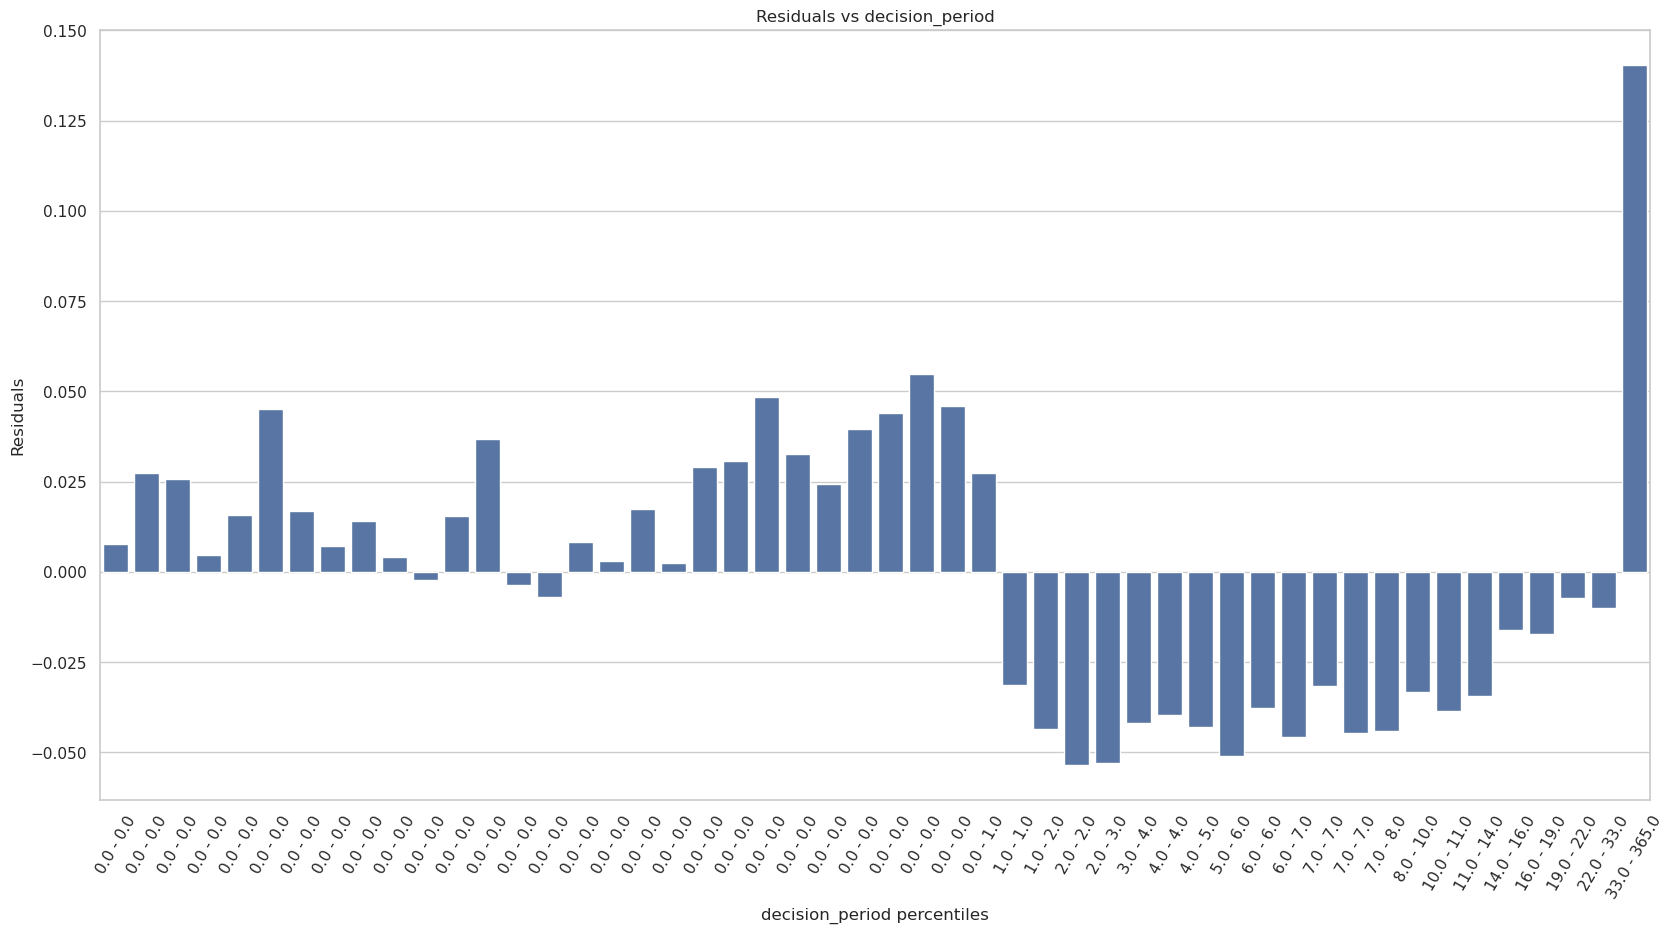

In [62]:
residuals_dp = utils.variable_vs_residuals_df(preprocessed_df = contracts_work,
                            variable2threshold = 'decision_period',                            
                            control_variables = control_variables,
                            number_of_quantiles = 50)
utils.plot_variableVSresiduals(df_varVSresiduals = residuals_dp, 
                        variable2threshold = 'decision_period',
                        wthresholds_plot = False)

In [63]:
#show the quantiles
contracts_work['decision_period'].quantile([0.33, 0.66, 1])

0.33      0.0
0.66      3.0
1.00    365.0
Name: decision_period, dtype: float64

In [64]:
#show the quantiles
contracts_work['decision_period'].quantile([0.5, 0.75, 1])

0.50      0.0
0.75      6.0
1.00    365.0
Name: decision_period, dtype: float64

single_bidder ~ decision_period+contract_year_2018+contract_year_2019+contract_year_2020+contract_year_2021+contract_year_2022+contract_price_decile+supply_type_goods+supply_type_services+supply_type_works+region_aguascalientes+region_bajacalifornia+region_bajacaliforniasur+region_campeche+region_chiapas+region_chihuahua+region_ciudaddemexico+region_coahuila+region_colima+region_durango+region_guanajuato+region_guerrero+region_hidalgo+region_jalisco+region_mexico+region_michoacan+region_morelos+region_nayarit+region_nuevoleon+region_oaxaca+region_puebla+region_queretaro+region_quintanaroo+region_sanluispotosi+region_sinaloa+region_sonora+region_tabasco+region_tamaulipas+region_tlaxcala+region_veracruz+region_yucatan+region_zacatecas
Optimization terminated successfully.
         Current function value: 0.291535
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.282542
         Iterations 8


/mnt/sdb1/marti/detecting_corruption_mexico/scripts/dataset_creation/utils.py:150: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2process['residuals'] = logit_model.resid_response


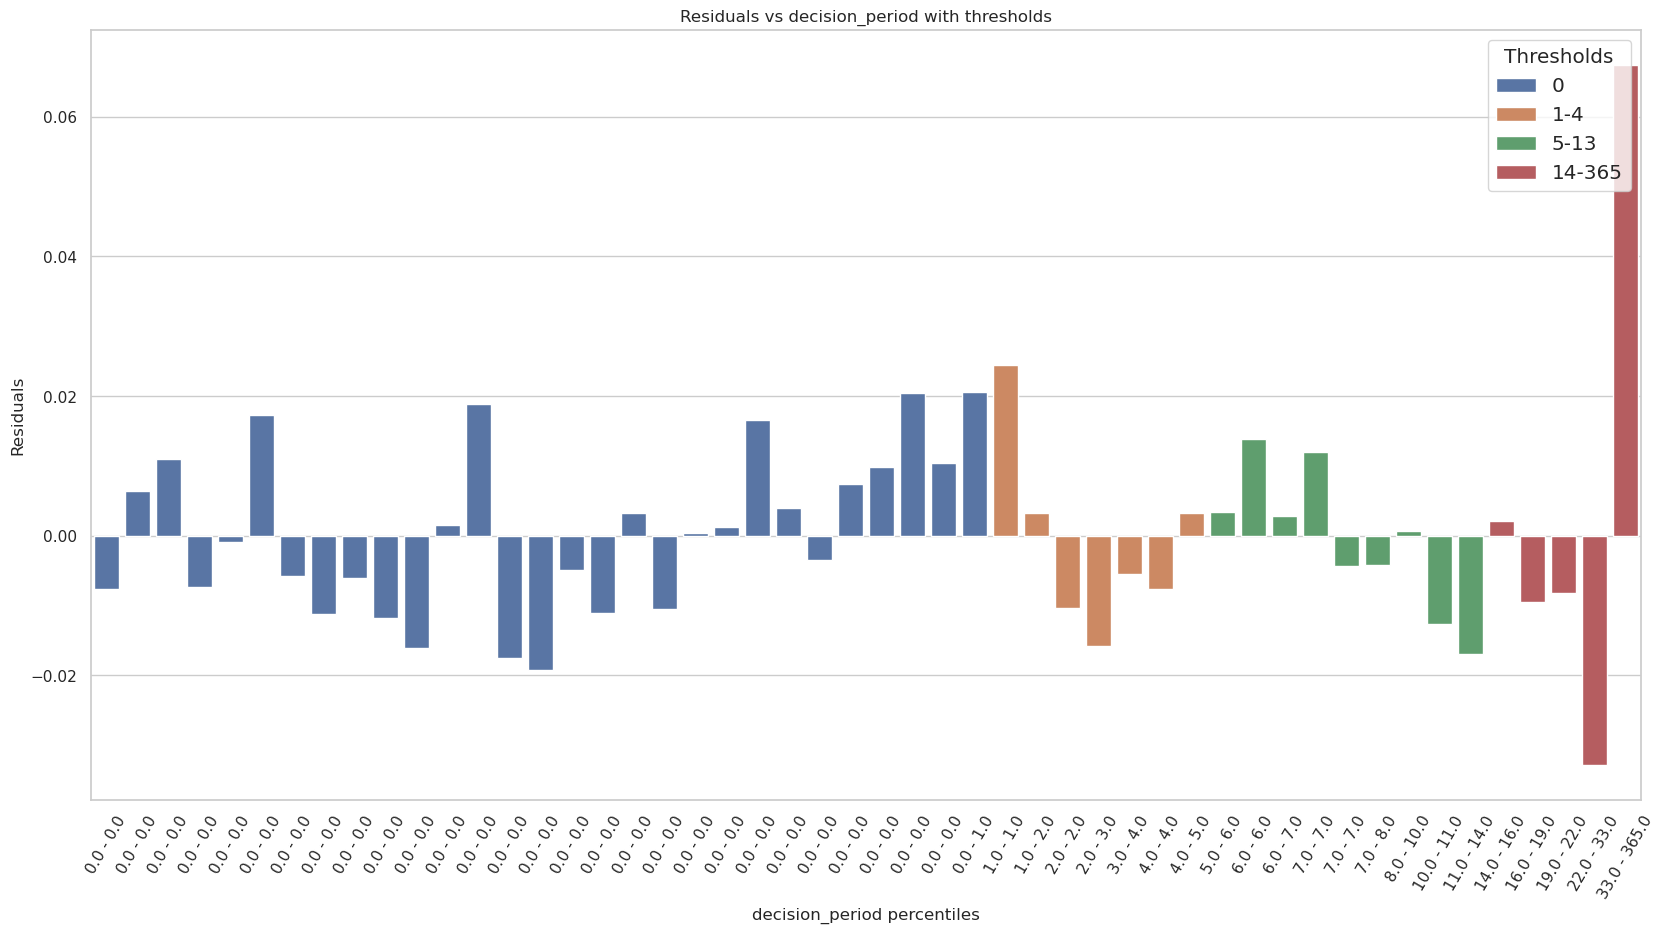

In [65]:
#decision_period_bins = [-1, 0, 6, 366]
decision_period_bins = [-1, 0, 4, 13, 366]
decision_period_binslabels = ['0', '1-4', '5-13', '14-365']


residuals_dp_wt = utils.variable_vs_residuals_df(preprocessed_df = contracts_work,
                            variable2threshold = 'decision_period',                            
                            control_variables = control_variables,
                            number_of_quantiles = 50,
                            thresholds_m = decision_period_bins,
                            thresholds_labels = decision_period_binslabels)

utils.plot_variableVSresiduals(df_varVSresiduals = residuals_dp_wt, 
                        variable2threshold = 'decision_period',
                        wthresholds_plot = True)
                            

In [66]:
contracts_work = contracts_work.drop(columns=['thresholds_levels'])

### include missing values

In [67]:
contracts_work['submission_period_t'] = pd.cut(contracts_work['submission_period'], submission_period_bins, labels = submission_period_binslabels)
contracts_work['decision_period_t'] = pd.cut(contracts_work['decision_period'], decision_period_bins, labels = decision_period_binslabels)

In [68]:
contracts_work['submission_period_t'] = np.where(contracts_work['submission_period_t'].isnull(), 'missing', contracts_work['submission_period_t'])
contracts_work['decision_period_t'] = np.where(contracts_work['decision_period_t'].isnull(), 'missing', contracts_work['decision_period_t'])

In [69]:
(contracts_work.isnull().sum()).sort_index()

bl_conformity                  0
buyer_dependence               0
contract_initial_date          0
contract_price_decile          0
contract_price_mx              0
contract_year_2018             0
contract_year_2019             0
contract_year_2020             0
contract_year_2021             0
contract_year_2022             0
decision_period             1579
decision_period_t              0
procedure_type_fixed           0
purchasing_unit_id             0
region_aguascalientes          0
region_bajacalifornia          0
region_bajacaliforniasur       0
region_campeche                0
region_chiapas                 0
region_chihuahua               0
region_ciudaddemexico          0
region_coahuila                0
region_colima                  0
region_durango                 0
region_guanajuato              0
region_guerrero                0
region_hidalgo                 0
region_jalisco                 0
region_mexico                  0
region_michoacan               0
region_mor

### Replace continuous variables with thresholded variables for logit

In [70]:
print('#################################### - submission period')
print(submission_period_bins)
print(submission_period_binslabels)
#reference_sp = submission_period_binslabels[-1]
reference_sp = '12-365'
print(reference_sp)
print('#################################### - decision period')
print(decision_period_bins)
print(decision_period_binslabels)
reference_dp = decision_period_binslabels[-1]
print(reference_dp)
print('#################################### - procedure type')
print(contracts_work['procedure_type_fixed'].unique())
reference_ptf = 'open'
print(reference_ptf)
print('#################################### - buyer dependence')
print(contracts_work['bl_conformity'].unique())
reference_blc = '3_high_conformity'
print(reference_blc)


#################################### - submission period
[-1, 5, 11, 366]
['0-5', '6-11', '12-365']
12-365
#################################### - decision period
[-1, 0, 4, 13, 366]
['0', '1-4', '5-13', '14-365']
14-365
#################################### - procedure type
['open', 'direct_failed_open', 'at_least_three']
Categories (3, object): ['open', 'direct_failed_open', 'at_least_three']
open
#################################### - buyer dependence
['0_no_conformity', '2_acceptable_conformity', '1_marginally_acceptable', 'non_applicable', '3_high_conformity']
Categories (5, object): ['0_no_conformity', '2_acceptable_conformity', '1_marginally_acceptable', 'non_applicable', '3_high_conformity']
3_high_conformity


In [71]:
#for submission period
contracts_work['submission_period_t'] = contracts_work['submission_period_t'].astype('category')
categories_spt = contracts_work['submission_period_t'].cat.categories.tolist()
categories_spt.remove(reference_sp)
categories_spt = [reference_sp] + categories_spt
contracts_work['submission_period_t'] = contracts_work['submission_period_t'].cat.reorder_categories(categories_spt, ordered=False)

#for decision period
contracts_work['decision_period_t'] = contracts_work['decision_period_t'].astype('category')
categories_dpt = contracts_work['decision_period_t'].cat.categories.tolist()
categories_dpt.remove(reference_dp)
categories_dpt = [reference_dp] + categories_dpt
contracts_work['decision_period_t'] = contracts_work['decision_period_t'].cat.reorder_categories(categories_dpt, ordered=False)

#for procedure type
contracts_work['procedure_type_fixed'] = contracts_work['procedure_type_fixed'].astype('category')
categories_ptf = contracts_work['procedure_type_fixed'].cat.categories.tolist()
categories_ptf.remove(reference_ptf)
categories_ptf = [reference_ptf] + categories_ptf
contracts_work['procedure_type_fixed'] = contracts_work['procedure_type_fixed'].cat.reorder_categories(categories_ptf, ordered=False)

#for buyer dependence
contracts_work['bl_conformity'] = contracts_work['bl_conformity'].astype('category')
categories_blc = contracts_work['bl_conformity'].cat.categories.tolist()
categories_blc.remove(reference_blc)
categories_blc = [reference_blc] + categories_blc
contracts_work['bl_conformity'] = contracts_work['bl_conformity'].cat.reorder_categories(categories_blc, ordered=False)

In [72]:
#see the categories of the variables
print(contracts_work['submission_period_t'].cat.categories)
print(contracts_work['decision_period_t'].cat.categories)
print(contracts_work['procedure_type_fixed'].cat.categories)
print(contracts_work['bl_conformity'].cat.categories)

Index(['12-365', '0-5', '6-11', 'missing'], dtype='object')
Index(['14-365', '0', '1-4', '5-13', 'missing'], dtype='object')
Index(['open', 'at_least_three', 'direct_failed_open'], dtype='object')
Index(['3_high_conformity', '0_no_conformity', '1_marginally_acceptable',
       '2_acceptable_conformity', 'non_applicable'],
      dtype='object')


In [73]:
contracts_work.columns

Index(['supplier_name_clean', 'contract_initial_date', 'contract_price_mx',
       'purchasing_unit_id', 'single_bidder', 'procedure_type_fixed',
       'submission_period', 'decision_period', 'buyer_dependence',
       'bl_conformity', 'contract_price_decile', 'contract_year_2018',
       'contract_year_2019', 'contract_year_2020', 'contract_year_2021',
       'contract_year_2022', 'supply_type_goods', 'supply_type_services',
       'supply_type_works', 'region_aguascalientes', 'region_bajacalifornia',
       'region_bajacaliforniasur', 'region_campeche', 'region_chiapas',
       'region_chihuahua', 'region_ciudaddemexico', 'region_coahuila',
       'region_colima', 'region_durango', 'region_guanajuato',
       'region_guerrero', 'region_hidalgo', 'region_jalisco', 'region_mexico',
       'region_michoacan', 'region_morelos', 'region_nayarit',
       'region_nuevoleon', 'region_oaxaca', 'region_puebla',
       'region_queretaro', 'region_quintanaroo', 'region_sanluispotosi',
       'r

# Logit

In [74]:
formula = ' '.join(dependent_variable) + ' ~ ' + '+'.join(contracts_work[independent_variables + control_variables].columns)
#replace values of the formula
formula = formula.replace('submission_period', 'submission_period_t')
formula = formula.replace('decision_period', 'decision_period_t')

print(formula)

single_bidder ~ procedure_type_fixed+submission_period_t+decision_period_t+buyer_dependence+bl_conformity+contract_year_2018+contract_year_2019+contract_year_2020+contract_year_2021+contract_year_2022+contract_price_decile+supply_type_goods+supply_type_services+supply_type_works+region_aguascalientes+region_bajacalifornia+region_bajacaliforniasur+region_campeche+region_chiapas+region_chihuahua+region_ciudaddemexico+region_coahuila+region_colima+region_durango+region_guanajuato+region_guerrero+region_hidalgo+region_jalisco+region_mexico+region_michoacan+region_morelos+region_nayarit+region_nuevoleon+region_oaxaca+region_puebla+region_queretaro+region_quintanaroo+region_sanluispotosi+region_sinaloa+region_sonora+region_tabasco+region_tamaulipas+region_tlaxcala+region_veracruz+region_yucatan+region_zacatecas


In [75]:
logit_model_c = smf.logit(formula, data= contracts_work).fit()

Optimization terminated successfully.
         Current function value: 0.276385
         Iterations 8


In [76]:
print(logit_model_c.summary())

                           Logit Regression Results                           
Dep. Variable:          single_bidder   No. Observations:               272641
Model:                          Logit   Df Residuals:                   272585
Method:                           MLE   Df Model:                           55
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                  0.1725
Time:                        23:48:17   Log-Likelihood:                -75354.
converged:                       True   LL-Null:                       -91066.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -3.3880      0.082    -41.207      0.000      -3.549      -3.227
procedure_type_fixed[T.at_least_thr

In [77]:
# do either
print(logit_model_c.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}                                 &  single\_bidder  & \textbf{  No. Observations:  } &   272641    \\
\textbf{Model:}                                         &      Logit       & \textbf{  Df Residuals:      } &   272585    \\
\textbf{Method:}                                        &       MLE        & \textbf{  Df Model:          } &       55    \\
\textbf{Date:}                                          & Fri, 10 Apr 2026 & \textbf{  Pseudo R-squ.:     } &   0.1725    \\
\textbf{Time:}                                          &     23:48:37     & \textbf{  Log-Likelihood:    } &   -75354.   \\
\textbf{converged:}                                     &       True       & \textbf{  LL-Null:           } &   -91066.   \\
\textbf{Covariance Type:}                               &    nonrobust     & \textbf{  LLR p-value:       } &    0.000    \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
                            

In [78]:
print('#################################### - submission period')
print(submission_period_bins)
print(submission_period_binslabels)
#reference_sp = submission_period_binslabels[-1]
reference_sp = '6-11'
print(reference_sp)

#for submission period
contracts_work['submission_period_t'] = contracts_work['submission_period_t'].astype('category')
categories_spt = contracts_work['submission_period_t'].cat.categories.tolist()
categories_spt.remove(reference_sp)
categories_spt = [reference_sp] + categories_spt
contracts_work['submission_period_t'] = contracts_work['submission_period_t'].cat.reorder_categories(categories_spt, ordered=False)


#################################### - submission period
[-1, 5, 11, 366]
['0-5', '6-11', '12-365']
6-11


In [79]:
formula = ' '.join(dependent_variable) + ' ~ ' + '+'.join(contracts_work[independent_variables + control_variables].columns)
#replace values of the formula
formula = formula.replace('submission_period', 'submission_period_t')
formula = formula.replace('decision_period', 'decision_period_t')
# formula = formula.replace('procedure_type_fixed', reference_ptf_l)
# formula = formula.replace('bl_conformity', reference_blc_l)

print(formula)

single_bidder ~ procedure_type_fixed+submission_period_t+decision_period_t+buyer_dependence+bl_conformity+contract_year_2018+contract_year_2019+contract_year_2020+contract_year_2021+contract_year_2022+contract_price_decile+supply_type_goods+supply_type_services+supply_type_works+region_aguascalientes+region_bajacalifornia+region_bajacaliforniasur+region_campeche+region_chiapas+region_chihuahua+region_ciudaddemexico+region_coahuila+region_colima+region_durango+region_guanajuato+region_guerrero+region_hidalgo+region_jalisco+region_mexico+region_michoacan+region_morelos+region_nayarit+region_nuevoleon+region_oaxaca+region_puebla+region_queretaro+region_quintanaroo+region_sanluispotosi+region_sinaloa+region_sonora+region_tabasco+region_tamaulipas+region_tlaxcala+region_veracruz+region_yucatan+region_zacatecas


In [80]:
logit_model_c = smf.logit(formula, data= contracts_work).fit()

Optimization terminated successfully.
         Current function value: 0.276385
         Iterations 8


In [81]:
print(logit_model_c.summary())

                           Logit Regression Results                           
Dep. Variable:          single_bidder   No. Observations:               272641
Model:                          Logit   Df Residuals:                   272585
Method:                           MLE   Df Model:                           55
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                  0.1725
Time:                        23:49:32   Log-Likelihood:                -75354.
converged:                       True   LL-Null:                       -91066.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -3.7107      0.085    -43.471      0.000      -3.878      -3.543
procedure_type_fixed[T.at_least_thr

In [82]:
# do either
print(logit_model_c.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}                                 &  single\_bidder  & \textbf{  No. Observations:  } &   272641    \\
\textbf{Model:}                                         &      Logit       & \textbf{  Df Residuals:      } &   272585    \\
\textbf{Method:}                                        &       MLE        & \textbf{  Df Model:          } &       55    \\
\textbf{Date:}                                          & Fri, 10 Apr 2026 & \textbf{  Pseudo R-squ.:     } &   0.1725    \\
\textbf{Time:}                                          &     23:49:33     & \textbf{  Log-Likelihood:    } &   -75354.   \\
\textbf{converged:}                                     &       True       & \textbf{  LL-Null:           } &   -91066.   \\
\textbf{Covariance Type:}                               &    nonrobust     & \textbf{  LLR p-value:       } &    0.000    \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
                            

# Weights

In [83]:
#get average marginal effects
av_marg_effects = logit_model_c.get_margeff()

In [84]:
print(av_marg_effects.summary())

        Logit Marginal Effects       
Dep. Variable:          single_bidder
Method:                          dydx
At:                           overall
                                                dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
procedure_type_fixed[T.at_least_three]         0.0092      0.002      4.378      0.000       0.005       0.013
procedure_type_fixed[T.direct_failed_open]     0.0912      0.004     20.493      0.000       0.082       0.100
submission_period_t[T.12-365]                  0.0257      0.002     13.379      0.000       0.022       0.029
submission_period_t[T.0-5]                     0.0363      0.002     23.326      0.000       0.033       0.039
submission_period_t[T.missing]                 0.1020      0.006     16.698      0.000       0.090       0.114
decision_period_t[T.0]                         0.0602      0.005     13

In [85]:
av_marg_effects_df = pd.DataFrame(av_marg_effects.summary().tables[1].data[1:], columns=av_marg_effects.summary().tables[1].data[0])
av_marg_effects_df.columns =['variable', 'ame', 'std err', 'z', 'P>|z|', '[0.025', '0.975]']
av_marg_effects_df = av_marg_effects_df[['variable', 'ame']]

In [86]:
av_marg_effects_df

,variable,ame
0,procedure_type_fixed[T.at_least_three],0.0092
1,procedure_type_fixed[T.direct_failed_open],0.0912
2,submission_period_t[T.12-365],0.0257
3,submission_period_t[T.0-5],0.0363
4,submission_period_t[T.missing],0.1020
5,decision_period_t[T.0],0.0602
6,decision_period_t[T.1-4],0.0399
7,decision_period_t[T.5-13],0.0137
8,decision_period_t[T.missing],0.0160
9,bl_conformity[T.0_no_conformity],0.0784


In [87]:
#get the names of the variables of the model
coef_names = logit_model_c.params.index.tolist()
#keep only the elements in the list that contain the strings in 'independent_variables'
coef_names = [x for x in coef_names if any(substring in x for substring in independent_variables)]


In [88]:
coef_names

['procedure_type_fixed[T.at_least_three]',
 'procedure_type_fixed[T.direct_failed_open]',
 'submission_period_t[T.12-365]',
 'submission_period_t[T.0-5]',
 'submission_period_t[T.missing]',
 'decision_period_t[T.0]',
 'decision_period_t[T.1-4]',
 'decision_period_t[T.5-13]',
 'decision_period_t[T.missing]',
 'bl_conformity[T.0_no_conformity]',
 'bl_conformity[T.1_marginally_acceptable]',
 'bl_conformity[T.2_acceptable_conformity]',
 'bl_conformity[T.non_applicable]',
 'buyer_dependence']

In [89]:
##Show coefficients of significant independent variables
var_weights = pd.DataFrame(logit_model_c.params.filter(items=coef_names)[logit_model_c.pvalues.filter(items=coef_names) < 0.05]).reset_index()
var_weights.columns = ['variable', 'logit_coefficient']
var_weights = pd.merge(var_weights, av_marg_effects_df, on = 'variable', how = 'left')
var_weights['ame'] = var_weights['ame'].astype(float)

#if ame is negative, then make it zero
var_weights['ame'] = np.where(var_weights['ame'] < 0, 0, var_weights['ame'])




In [90]:
var_weights

,variable,logit_coefficient,ame
0,procedure_type_fixed[T.at_least_three],0.115299,0.0092
1,procedure_type_fixed[T.direct_failed_open],1.146560,0.0912
2,submission_period_t[T.12-365],0.322714,0.0257
3,submission_period_t[T.0-5],0.456582,0.0363
4,submission_period_t[T.missing],1.282831,0.1020
5,decision_period_t[T.0],0.756476,0.0602
6,decision_period_t[T.1-4],0.500994,0.0399
7,decision_period_t[T.5-13],0.172760,0.0137
8,decision_period_t[T.missing],0.201672,0.0160
9,bl_conformity[T.0_no_conformity],0.985532,0.0784


In [91]:
#separate the variable name from the category
var_weights['category'] = var_weights['variable'].str.split('[').str[1].str.split(']').str[0]
#remove 'T.' from category
var_weights['category'] = var_weights['category'].str.replace('T.', '')
#keep only the variable name
var_weights['variable'] = var_weights['variable'].str.split('[').str[0]

#Make them strings
#var_weights['category'] = var_weights['category'].astype(str)
#var_weights['variable'] = var_weights['variable'].astype(str)

/mnt/sdb1/marti/miniconda3/envs/det_corr_mex_env/lib/python3.7/site-packages/ipykernel_launcher.py:4: FutureWarning: The default value of regex will change from True to False in a future version.
  after removing the cwd from sys.path.


In [92]:
var_weights

,variable,logit_coefficient,ame,category
0,procedure_type_fixed,0.115299,0.0092,at_least_three
1,procedure_type_fixed,1.146560,0.0912,direct_failed_open
2,submission_period_t,0.322714,0.0257,12-365
3,submission_period_t,0.456582,0.0363,0-5
4,submission_period_t,1.282831,0.1020,missing
5,decision_period_t,0.756476,0.0602,0
6,decision_period_t,0.500994,0.0399,1-4
7,decision_period_t,0.172760,0.0137,5-13
8,decision_period_t,0.201672,0.0160,missing
9,bl_conformity,0.985532,0.0784,0_no_conformity


In [93]:
#add the reference categories to the dataframe as rows
new_rows = pd.DataFrame({
    'variable': ['procedure_type_fixed', 'bl_conformity', 'submission_period_t', 'decision_period_t'],
    'logit_coefficient': [np.nan, np.nan, np.nan, np.nan],
    #'ame': [np.nan, np.nan, np.nan, np.nan],
    'ame': [0, 0, 0, 0],
    'category': [reference_ptf, reference_blc, reference_sp, reference_dp]
})

var_weights = pd.concat([var_weights, new_rows], ignore_index=True)




In [94]:
var_weights

,variable,logit_coefficient,ame,category
0,procedure_type_fixed,0.115299,0.0092,at_least_three
1,procedure_type_fixed,1.146560,0.0912,direct_failed_open
2,submission_period_t,0.322714,0.0257,12-365
3,submission_period_t,0.456582,0.0363,0-5
4,submission_period_t,1.282831,0.1020,missing
5,decision_period_t,0.756476,0.0602,0
6,decision_period_t,0.500994,0.0399,1-4
7,decision_period_t,0.172760,0.0137,5-13
8,decision_period_t,0.201672,0.0160,missing
9,bl_conformity,0.985532,0.0784,0_no_conformity


In [95]:
var_weights['ame_sum_per_variable'] = var_weights.groupby(['variable'])['ame'].transform('sum')
var_weights['weight_per_variable'] = var_weights['ame_sum_per_variable'] / var_weights['ame_sum_per_variable'].unique().sum()
var_weights['weight_per_category'] = var_weights.groupby('variable')['ame'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))
#var_weights['weight_per_category'] = var_weights['ame'] / var_weights['ame_sum_per_variable']

#i
#var_weights['category'] = np.where(var_weights['category'].isnull(), var_weights['variable'], var_weights['category'])

In [96]:
var_weights.sort_values(by= ['variable', 'category', 'ame'])

,variable,logit_coefficient,ame,category,ame_sum_per_variable,weight_per_variable,weight_per_category
9,bl_conformity,0.985532,0.0784,0_no_conformity,0.2332,0.319452,1.000000
10,bl_conformity,0.835160,0.0664,1_marginally_acceptable,0.2332,0.319452,0.846939
11,bl_conformity,0.401344,0.0319,2_acceptable_conformity,0.2332,0.319452,0.406888
15,bl_conformity,NaN,0.0000,3_high_conformity,0.2332,0.319452,0.000000
12,bl_conformity,0.709678,0.0565,non_applicable,0.2332,0.319452,0.720663
13,buyer_dependence,1.290006,0.1026,NaN,0.1026,0.140548,NaN
5,decision_period_t,0.756476,0.0602,0,0.1298,0.177808,1.000000
6,decision_period_t,0.500994,0.0399,1-4,0.1298,0.177808,0.662791
17,decision_period_t,NaN,0.0000,14-365,0.1298,0.177808,0.000000
7,decision_period_t,0.172760,0.0137,5-13,0.1298,0.177808,0.227575


# Red Flags creation

In [97]:
var_weights = var_weights.sort_values(by= ['variable' ,'ame', 'category' ]).reset_index(drop=True)

In [98]:
var_weights

,variable,logit_coefficient,ame,category,ame_sum_per_variable,weight_per_variable,weight_per_category
0,bl_conformity,NaN,0.0000,3_high_conformity,0.2332,0.319452,0.000000
1,bl_conformity,0.401344,0.0319,2_acceptable_conformity,0.2332,0.319452,0.406888
2,bl_conformity,0.709678,0.0565,non_applicable,0.2332,0.319452,0.720663
3,bl_conformity,0.835160,0.0664,1_marginally_acceptable,0.2332,0.319452,0.846939
4,bl_conformity,0.985532,0.0784,0_no_conformity,0.2332,0.319452,1.000000
5,buyer_dependence,1.290006,0.1026,NaN,0.1026,0.140548,NaN
6,decision_period_t,NaN,0.0000,14-365,0.1298,0.177808,0.000000
7,decision_period_t,0.172760,0.0137,5-13,0.1298,0.177808,0.227575
8,decision_period_t,0.201672,0.0160,missing,0.1298,0.177808,0.265781
9,decision_period_t,0.500994,0.0399,1-4,0.1298,0.177808,0.662791


In [99]:
def standardize_weights(df, var_name):
    target_values_s5 = [0, 0.25, 0.5, 0.75, 1]
    target_values_s4 = [0, 0.33, 0.66, 1]
    target_values_s3 = [0, 0.5, 1]

    var_weights_var = var_weights[var_weights['variable'] == var_name][['category', 'ame']].sort_values(by = 'ame').reset_index(drop=True)
    if len(var_weights_var) == 3:
        var_weights_var[var_name + '_standard'] = target_values_s3
    elif len(var_weights_var) == 4:
        var_weights_var[var_name + '_standard'] = target_values_s4
    elif len(var_weights_var) == 5:
        var_weights_var[var_name + '_standard'] = target_values_s5
    else:
        print('Error')

    standard_values_dict = dict(zip(var_weights_var['category'], var_weights_var[var_name + '_standard']))

    print(var_weights_var)

    return standard_values_dict
    

In [100]:
blc_standard = standardize_weights(var_weights, 'bl_conformity')

                  category     ame  bl_conformity_standard
0        3_high_conformity  0.0000                    0.00
1  2_acceptable_conformity  0.0319                    0.25
2           non_applicable  0.0565                    0.50
3  1_marginally_acceptable  0.0664                    0.75
4          0_no_conformity  0.0784                    1.00


In [101]:
dp_standard = standardize_weights(var_weights, 'decision_period_t')

  category     ame  decision_period_t_standard
0   14-365  0.0000                        0.00
1     5-13  0.0137                        0.25
2  missing  0.0160                        0.50
3      1-4  0.0399                        0.75
4        0  0.0602                        1.00


In [102]:
sp_standard = standardize_weights(var_weights, 'submission_period_t')

  category     ame  submission_period_t_standard
0     6-11  0.0000                          0.00
1   12-365  0.0257                          0.33
2      0-5  0.0363                          0.66
3  missing  0.1020                          1.00


In [103]:
ptf_standard = standardize_weights(var_weights, 'procedure_type_fixed')
#equalize direct with direct_failed_open
ptf_standard['direct'] = ptf_standard['direct_failed_open']

             category     ame  procedure_type_fixed_standard
0                open  0.0000                            0.0
1      at_least_three  0.0092                            0.5
2  direct_failed_open  0.0912                            1.0


In [104]:
#same transformations than for contracts work
#negative as missing
contracts['bl_conformity'] = np.where(contracts['bl_conformity'].isnull(), 'non_applicable', contracts['bl_conformity'])
contracts['submission_period'] = np.where(contracts['submission_period'] < 0, np.nan, contracts['submission_period'])
contracts['decision_period'] = np.where(contracts['decision_period'] < 0, np.nan, contracts['decision_period'])
#thresholds
contracts['submission_period_t'] = pd.cut(contracts['submission_period'], submission_period_bins, labels = submission_period_binslabels)
contracts['decision_period_t'] = pd.cut(contracts['decision_period'], decision_period_bins, labels = decision_period_binslabels)
#missing
contracts['submission_period_t'] = np.where(contracts['submission_period_t'].isnull(), 'missing', contracts['submission_period_t'])
contracts['decision_period_t'] = np.where(contracts['decision_period_t'].isnull(), 'missing', contracts['decision_period_t'])


In [105]:
contracts['rf_submission_period'] = contracts['submission_period_t'].map(sp_standard).astype(float)
contracts['rf_decision_period'] = contracts['decision_period_t'].map(dp_standard).astype(float)
contracts['rf_procedure_type'] = contracts['procedure_type_fixed'].map(ptf_standard).astype(float)
contracts['rf_bl_conformity'] = contracts['bl_conformity'].map(blc_standard).astype(float)

#rename buyer dependence column
contracts = contracts.rename(columns={'buyer_dependence': 'rf_buyer_dependence'})

In [106]:
#single bidder as a red flag
contracts = contracts.rename(columns={'single_bidder': 'rf_single_bidder'})

In [107]:
contracts.head()

,supplier_name_clean,contract_initial_date,contract_price_mx,purchasing_unit_id,rf_single_bidder,call_for_tender_publication,procedure_type,procedure_type_fixed,submission_period,decision_period,...,contract_price_decile,government_level,supply_type,state,submission_period_t,decision_period_t,rf_submission_period,rf_decision_period,rf_procedure_type,rf_bl_conformity
0,tcaempresarialsadecv,2011-12-14,146343.00,050GYR005,NaN,0,direct,direct_failed_open,NaN,NaN,...,5,federal_authority,goods,None,missing,missing,1.0,0.50,1.0,0.25
1,instrumentosyaccesoriosautomatizadossadecv,2011-12-15,6250.00,050GYR005,NaN,0,direct,direct_failed_open,NaN,NaN,...,0,federal_authority,goods,None,missing,missing,1.0,0.50,1.0,0.25
2,dacegacorporation,2011-12-22,54400.00,050GYR025,NaN,0,direct,direct_failed_open,NaN,6.0,...,3,federal_authority,goods,None,missing,5-13,1.0,0.25,1.0,1.00
3,lizbethapariciorazo,2011-10-03,88579.20,016000997,NaN,0,direct,direct_failed_open,NaN,10.0,...,4,federal_authority,goods,None,missing,5-13,1.0,0.25,1.0,1.00
4,victormiguelvallejojuarez,2011-09-20,163970.68,821045953,NaN,0,at_least_three,at_least_three,NaN,6.0,...,5,local_authority,services,None,missing,5-13,1.0,0.25,0.5,1.00


In [108]:
(contracts.isnull().sum() ).sort_index()

bl_conformity                        0
call_for_tender_publication          0
contract_initial_date                0
contract_price_decile                0
contract_price_mx                    0
contract_year                        0
decision_period                 700346
decision_period_t                    0
government_level                     0
procedure_type                    6120
procedure_type_fixed              6120
purchasing_unit_id                   0
rf_bl_conformity                     0
rf_buyer_dependence                  0
rf_decision_period                   0
rf_procedure_type                22732
rf_single_bidder               2030204
rf_submission_period                 0
state                           967605
submission_period              1228693
submission_period_t                  0
supplier_name_clean                  0
supply_type                       7501
dtype: int64

# Corruption Risk Index

There is a weighted and unweighted CRI.

The weighted takes into account how big is the effect of all the categories of a variable in relation with others

The unweighted is only the mean of the redflags

The correlation is 0.98, therefore i think it's better to keep the unweighted, also because it allows me to easily calculate the CRI for contractst that have missing values in some red flags

In [109]:
red_flags_columns = ['rf_submission_period', 'rf_decision_period', 'rf_procedure_type', 'rf_bl_conformity', 'rf_buyer_dependence', 'rf_single_bidder']
contracts['CRI'] = contracts[red_flags_columns].mean(axis=1, skipna=True)


In [110]:
contracts['CRI'].isnull().sum()

0

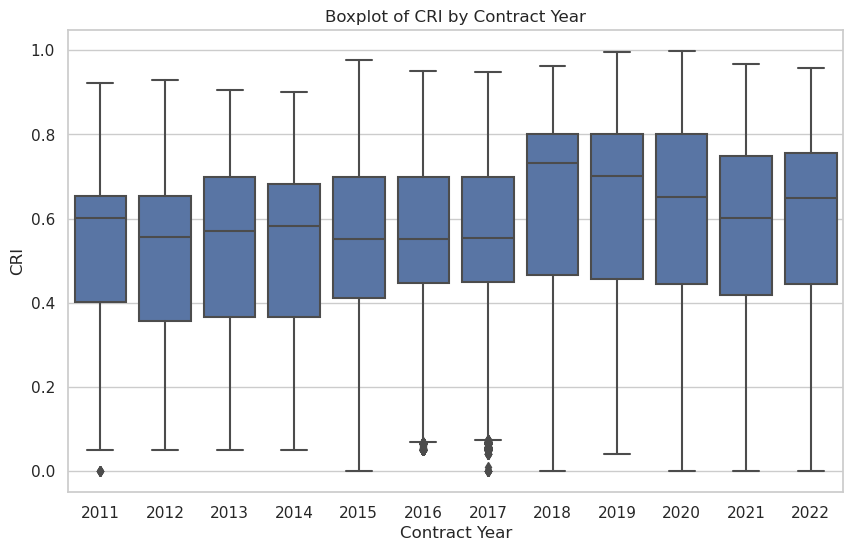

In [112]:
# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='contract_year', y='CRI', data=contracts, color = '#4c72b0')

# Add title and labels
plt.title('Boxplot of CRI by Contract Year')
plt.xlabel('Contract Year')
plt.ylabel('CRI')

# Show the plot
plt.show()

In [113]:
(contracts.isnull().sum()).sort_index()

CRI                                  0
bl_conformity                        0
call_for_tender_publication          0
contract_initial_date                0
contract_price_decile                0
contract_price_mx                    0
contract_year                        0
decision_period                 700346
decision_period_t                    0
government_level                     0
procedure_type                    6120
procedure_type_fixed              6120
purchasing_unit_id                   0
rf_bl_conformity                     0
rf_buyer_dependence                  0
rf_decision_period                   0
rf_procedure_type                22732
rf_single_bidder               2030204
rf_submission_period                 0
state                           967605
submission_period              1228693
submission_period_t                  0
supplier_name_clean                  0
supply_type                       7501
dtype: int64

In [114]:
var2keep = [
    #identifiers
    'supplier_name_clean',
    'contract_initial_date',
    'contract_price_mx',
    'purchasing_unit_id',
    'contract_year',

    #red flags
    'CRI',
    'rf_submission_period',
    'rf_decision_period',
    'rf_procedure_type',
    'rf_bl_conformity',
    'rf_buyer_dependence',
    'rf_single_bidder',

    #red flags components
    'submission_period_t',
    'decision_period_t']

In [115]:
contracts = contracts[var2keep]

In [116]:
(contracts.isnull().sum()).sort_index()

CRI                            0
contract_initial_date          0
contract_price_mx              0
contract_year                  0
decision_period_t              0
purchasing_unit_id             0
rf_bl_conformity               0
rf_buyer_dependence            0
rf_decision_period             0
rf_procedure_type          22732
rf_single_bidder         2030204
rf_submission_period           0
submission_period_t            0
supplier_name_clean            0
dtype: int64

In [117]:
contracts['prov_id'] = contracts.index

In [118]:
#save the dataframe as feather
contracts.to_feather(processed_data / 'mxc_11to22_cri.feather')
